# B06 · Mitra: the prior is part of the model

**Skill:** isolate generator effects while preserving a matched learner and evaluation contract. PROVIDED shows implementation; TODO is your work; CHECK gives immediate feedback; EXIT asks for a written defense.

The default executes your functions, a fresh one-update mechanism check, and inference from all nine saved course checkpoints. It does **not** rerun full pretraining or the nine author fits. A separate gated command regenerates all nine fits. Original Table12 is source-gated, not implemented as an exact trainer.

Python3.11+,NumPy,PyTorch. Author environment:NumPy2.5.0,PyTorch2.13.0+cpu. NoGPU required. The archive is embedded for portability; no repository checkout needed. Live Colab NOT_CHECKED. Learner PENDING_WRITTEN_DEFENSE.

## Concept recap

A prior is a distribution of whole tasks. A generator samples a task. An outer mixture draws one generator per table; a hybrid generator combines mechanisms within a table. Changing a prior can change what a fixed architecture learns.

Support rows supply labels; query labels only score outputs. With24support+8query rows and4features, the learner embeds32×5cells. Two blocks mix columns within rows and read support across rows. Query labels never enter its forward signature.

For u=.4 and p=.5 choose SCM. For support[1,3], mean2 and standard deviation1 transform query5 to3. Lower cross-entropy is better; constant p=.5 gives0.693147. Before viewing results, predict whether all controlled experiments necessarily learn useful ICL.


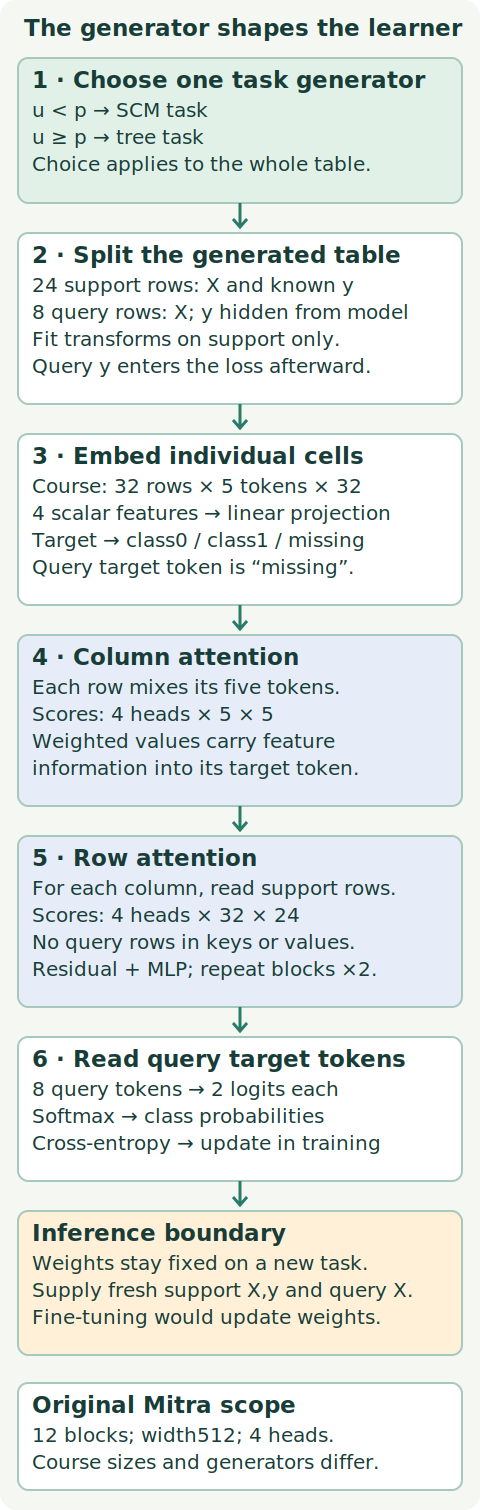

Mitra concept and course trace; original12×512 differs from course2×32.

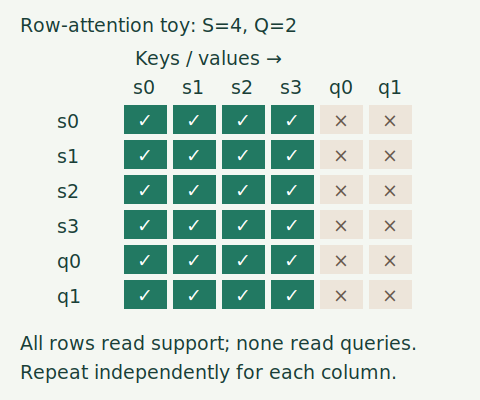

Toy attention permissions, S4/Q2. The measured course uses S24/Q8.

In [1]:
# @colab-bootstrap: install only missing dependencies; no repository needed.
import importlib.util, subprocess, sys
for module, package in [('numpy','numpy==2.5.0'),('torch','torch==2.13.0')]:
    if importlib.util.find_spec(module) is None:
        subprocess.check_call([sys.executable,'-m','pip','install',package])
import ast, base64, hashlib, io, json, math, statistics, zipfile, copy
from pathlib import Path
import numpy as np
import torch
from torch import nn
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)


In [2]:
payload = '...'
raw=base64.b64decode(payload)
assert hashlib.sha256(raw).hexdigest()=='3860dc6725a4438b7c9e0e5bf4f1fdb2d2cf09a5e90ee257bb950957df733864'
workspace=Path('b06-portable'); workspace.mkdir(exist_ok=True)
with zipfile.ZipFile(io.BytesIO(raw)) as bundle: bundle.extractall(workspace)
lab=workspace/'labs'; evidence=lab/'evidence/b06'
config=json.loads((evidence/'course-protocol.json').read_text())
print('Authenticated portable course/source package')

Authenticated portable course/source package


## TODO 1 · Choose the whole-task generator

Implement interval validation and the two-family choice. Predict the p=0 and p=1 behavior.

In [3]:
def choose_prior(u, p):
    """Outer mixture: one entire task comes from exactly one generator."""
    if not np.isfinite(u) or not np.isfinite(p) or not 0 <= u < 1 or not 0 <= p <= 1:
        raise ValueError('u must lie in [0,1); p in [0,1]')
    return 'scm' if u < p else 'tree'

In [4]:
def check_prior(fn):
    assert [fn(x,.5) for x in [0,.49,.5,.99]] == ['scm','scm','tree','tree']
    assert fn(0,0)=='tree' and fn(.999,1)=='scm'
    for u,p in [(-.1,.5),(1,.5),(.3,1.1),(float('nan'),.5)]:
        try:fn(u,p)
        except ValueError:pass
        else:raise AssertionError('Reject invalid mixture probabilities/uniform draws')
check_prior(choose_prior)
print("Learner contract passes")

Learner contract passes


## TODO 2 · Restrict information access

Fit means and population scales on support only. Preserve input arrays. A changed query must not change transformed support.

In [5]:
def support_normalize(support, query):
    """Population statistics from support only; constant columns have scale1e-6."""
    support=np.asarray(support,dtype=np.float64);query=np.asarray(query,dtype=np.float64)
    mean=support.mean(axis=0);scale=np.maximum(support.std(axis=0),1e-6)
    return (support-mean)/scale,(query-mean)/scale

In [6]:
def check_normalize(fn):
    s=np.array([[1.,7.],[3.,7.]])
    q=np.array([[5.,9.]])
    a,b=fn(s,q)
    np.testing.assert_allclose(a,[[-1,0],[1,0]])
    np.testing.assert_allclose(b,[[3,2e6]])
    c,d=fn(s,q*100)
    np.testing.assert_array_equal(a,c)
    np.testing.assert_array_equal(s,[[1,7],[3,7]])
    assert np.isfinite(d).all()
check_normalize(support_normalize)
print("Learner contract passes")

Learner contract passes


## TODO 3 · Pair by identity

Require identical nonempty seed-key sets; return left-minus-right in sorted identity order. Insertion order is not identity.

In [7]:
def paired_effect(left, right):
    """Match seed IDs before subtracting; positive means larger left metric."""
    if set(left)!=set(right) or not left:
        raise ValueError('Nonempty, identical paired identities required')
    return np.array([left[key]-right[key] for key in sorted(left)])

In [8]:
def check_pair(fn):
    a={'seed0':.4,'seed1':.8};b={'seed1':.3,'seed0':.2}
    np.testing.assert_allclose(fn(a,b),[.2,.5])
    try:fn(a,{'seed0':.1,'seed2':.9})
    except ValueError:pass
    else:raise AssertionError('Mismatched seed identities accepted')
check_pair(paired_effect)
print("Learner contract passes")

Learner contract passes


## PROVIDED · Generate task distributions

Course proxies: triangular nonlinear SCM, depth-two tree, additive hybrid. Support score median fixes class boundary. The hybrid family appears only at evaluation.

In [9]:
def make_task(family, seed, config):
    """Course proxy generators. Four features, noisy binary target; fixed support cut."""
    if family not in ['scm','tree','hybrid']:raise ValueError('Unknown family')
    rng=np.random.default_rng(seed);n=config['support']+config['query'];f=config['features']
    x=rng.normal(size=(n,f));weights=rng.normal(size=(f,f))
    # Lower-triangular structural equations create feature dependence.
    if family in ['scm','hybrid']:
        for j in range(1,f):x[:,j]+=np.tanh(x[:,:j]@weights[:j,j])/np.sqrt(j)
    neural=np.tanh(x@rng.normal(size=f))+0.3*np.sin(x[:,0]*rng.uniform(.5,2))
    axes=rng.integers(0,f,size=3);thresholds=rng.uniform(-.5,.5,size=3)
    root=x[:,axes[0]]>thresholds[0]
    child=np.where(root,x[:,axes[2]]>thresholds[2],x[:,axes[1]]>thresholds[1])
    leaves=rng.normal(size=4);tree=leaves[2*root.astype(int)+child.astype(int)]
    score={'scm':neural,'tree':tree,'hybrid':.5*neural+.5*tree}[family]
    score=score+.15*rng.normal(size=n)
    # Support-derived boundary avoids fitting any transform to query labels.
    y=(score>np.median(score[:config['support']])).astype(np.int64)
    a,b=support_normalize(x[:config['support']],x[config['support']:])
    return dict(x=np.concatenate([a,b]),y=y,raw_x=x)

## PROVIDED · Cell-token learner

Follow x→feature embeddings and support_y→label tokens. A missing target uses token2. Column attention reads each row; row attention uses support-only keys/values. The query target token feeds the binary head.

In [10]:
class CellBlock(nn.Module):
    """Column self-attention then row attention with support-only keys/values."""
    def __init__(self,width,heads):
        super().__init__()
        self.column=nn.MultiheadAttention(width,heads,batch_first=True,dropout=0)
        self.row=nn.MultiheadAttention(width,heads,batch_first=True,dropout=0)
        self.n1=nn.LayerNorm(width);self.n2=nn.LayerNorm(width);self.n3=nn.LayerNorm(width)
        self.ff=nn.Sequential(nn.Linear(width,2*width),nn.GELU(),nn.Linear(2*width,width))
    def forward(self,h,s):
        b,n,c,d=h.shape
        z=self.n1(h).reshape(b*n,c,d)
        h=h+self.column(z,z,z,need_weights=False)[0].reshape(b,n,c,d)
        z=self.n2(h).permute(0,2,1,3).reshape(b*c,n,d)
        update=self.row(z,z[:,:s],z[:,:s],need_weights=False)[0]
        h=h+update.reshape(b,c,n,d).permute(0,2,1,3)
        return h+self.ff(self.n3(h))

class CellLearner(nn.Module):
    """Small course 2D learner: scalar cells -> 2 blocks -> query target-token logits."""
    def __init__(self,config):
        super().__init__();d=config['width'];self.support=config['support']
        self.value=nn.Linear(1,d);self.label=nn.Embedding(3,d)
        self.blocks=nn.ModuleList([CellBlock(d,config['heads']) for _ in range(config['layers'])])
        self.head=nn.Sequential(nn.LayerNorm(d),nn.Linear(d,2))
    def forward(self,x,support_y):
        b,n,f=x.shape;s=self.support
        if support_y.shape!=(b,s):raise ValueError('Pass support labels only')
        # Label token2 is a missing label, not a third output class.
        labels=torch.full((b,n),2,dtype=torch.long,device=x.device)
        labels[:,:s]=support_y
        h=torch.cat([self.value(x.unsqueeze(-1)),self.label(labels).unsqueeze(2)],dim=2)
        for block in self.blocks:h=block(h,s)
        return self.head(h[:,s:,-1])

## PROVIDED · Matched trainer and predictor

All three arms share initialization per seed.160updates×4tasks; balanced shuffled mixture counts. Query labels enter cross-entropy outside forward. Final checkpoint only; no test-based selection.

In [11]:
def state_hash(model):
    h=hashlib.sha256()
    for key,value in sorted(model.state_dict().items()):
        h.update(key.encode());h.update(value.detach().cpu().numpy().tobytes())
    return h.hexdigest()

def train_one(config,arm,seed):
    """Matched fresh fit. Final checkpoint only; no test-driven selection."""
    torch.manual_seed(seed);model=CellLearner(config);initial=state_hash(model)
    optimizer=torch.optim.AdamW(model.parameters(),lr=config['learning_rate'],weight_decay=config['weight_decay'])
    count=config['steps']*config['batch_tasks'];u=(np.arange(count)+.5)/count
    np.random.default_rng(seed+8000).shuffle(u)
    schedule=[choose_prior(float(v),config['arms'][arm]) for v in u]
    trace=[];model.train()
    for step in range(config['steps']):
        tasks=[]
        for j in range(config['batch_tasks']):
            i=step*config['batch_tasks']+j
            tasks.append(make_task(schedule[i],config['training_seed_base']+config['training_seed_stride']*seed+i,config))
        x=torch.tensor(np.stack([t['x'] for t in tasks]),dtype=torch.float32)
        y=torch.tensor(np.stack([t['y'] for t in tasks]))
        optimizer.zero_grad();logits=model(x,y[:,:config['support']])
        loss=nn.functional.cross_entropy(logits.flatten(0,1),y[:,config['support']:].flatten())
        loss.backward();optimizer.step();trace.append(float(loss.detach()))
    return model,dict(initial_sha256=initial,final_sha256=state_hash(model),loss=trace,prior_counts={f:schedule.count(f) for f in ['scm','tree']},schedule=schedule)

def predict_tasks(model,tasks,config):
    model.eval();s=config['support'];rows=[]
    with torch.no_grad():
        for task in tasks:
            x=torch.tensor(np.array(task['x'])[None],dtype=torch.float32)
            support_y=torch.tensor([task['y'][:s]],dtype=torch.long)
            logits=model(x,support_y)[0].double();prob=torch.softmax(logits,dim=-1).numpy()
            for j,(y,p) in enumerate(zip(task['y'][s:],prob)):
                rows.append(dict(task_id=task['id'],family=task['family'],query_id=s+j,y=int(y),p=p.tolist()))
    return rows

## CHECK · Your functions control real computation

Monkey-patched counters verify that the visible trainer and generator call your functions. This fresh **one-update probe** is not the nine-fit result. Predictions from each saved course checkpoint must then match the immutable records.

In [12]:
counter={'prior':0,'normalize':0}
_saved_prior=choose_prior; _saved_normalize=support_normalize
def counted_prior(*args):
    counter['prior']+=1
    return _saved_prior(*args)
def counted_normalize(*args):
    counter['normalize']+=1
    return _saved_normalize(*args)
choose_prior=counted_prior; support_normalize=counted_normalize
probe_config=dict(config,steps=1)
probe,trace=train_one(probe_config,'mixed',0)
assert counter=={'prior':4,'normalize':4}
choose_prior=_saved_prior; support_normalize=_saved_normalize
assert trace['initial_sha256']!=trace['final_sha256']
tasks=json.loads((evidence/'runs/tasks.json').read_text())
maximum=0.0
for seed in config['seeds']:
    for arm in config['arms']:
        saved=json.loads((evidence/f'runs/run-{arm}-{seed}.json').read_text())
        model=CellLearner(config)
        model.load_state_dict(torch.load(evidence/f'runs/weights-{arm}-{seed}.pt',weights_only=True,map_location='cpu'))
        regenerated=predict_tasks(model,tasks,config)
        assert len(regenerated)==len(saved['records'])==480
        for a,b in zip(regenerated,saved['records']):
            assert (a['task_id'],a['query_id'],a['y'])==(b['task_id'],b['query_id'],b['y'])
            maximum=max(maximum,max(abs(x-y) for x,y in zip(a['p'],b['p'])))
assert maximum<=1e-7
print('4320 saved-checkpoint predictions regenerated; maximum error',maximum)


4320 saved-checkpoint predictions regenerated; maximum error 0.0


## PROVIDED · Independent scalar audit

Read the identity checks before the scorer. It does not import the model. Fixed equal query counts make the record mean equal the equal-task mean. This is saved-evidence verification, not fresh pretraining.

In [13]:
def audit_course(root):
    root=Path(root);cpath=root/'course-protocol.json';c=json.loads(cpath.read_text());runs=root/'runs'
    tasks=json.loads((runs/'tasks.json').read_text());taskmap={t['id']:t for t in tasks}
    expected={(t['id'],j) for t in tasks for j in range(c['support'],c['support']+c['query'])}
    assert len(taskmap)==len(tasks)==60 and len(expected)==480
    training_seeds={c['training_seed_base']+c['training_seed_stride']*seed+i for seed in c['seeds'] for i in range(c['steps']*c['batch_tasks'])}
    assert not training_seeds.intersection(t['seed'] for t in tasks)
    summary=[];initial={};final={};identities={};total=0
    actual={(p.stem.split('-')[1],int(p.stem.split('-')[2])) for p in runs.glob('run-*.json')}
    assert actual=={(a,s) for a in c['arms'] for s in c['seeds']},'Incomplete or extra runs'
    for seed in c['seeds']:
        for arm,p in c['arms'].items():
            r=json.loads((runs/f'run-{arm}-{seed}.json').read_text());assert (r['arm'],r['seed'])==(arm,seed)
            ident=r['identity'];assert ident['protocol_sha256']==hashlib.sha256(cpath.read_bytes()).hexdigest()
            assert ident['task_sha256']==hashlib.sha256((runs/'tasks.json').read_bytes()).hexdigest()
            identities[(arm,seed)]=ident;initial[(arm,seed)]=r['training']['initial_sha256'];final[(arm,seed)]=r['training']['final_sha256']
            assert hashlib.sha256((runs/f'weights-{arm}-{seed}.pt').read_bytes()).hexdigest()==r['weights_sha256']
            assert len(r['training']['loss'])==c['steps'] and all(math.isfinite(x) for x in r['training']['loss'])
            counts=r['training']['prior_counts'];n=c['steps']*c['batch_tasks'];assert counts=={'scm':int(n*p),'tree':n-int(n*p)}
            schedule=r['training']['schedule'];assert len(schedule)==n and {k:schedule.count(k) for k in counts}==counts
            keys=[(x['task_id'],x['query_id']) for x in r['records']]
            assert len(keys)==len(set(keys)) and set(keys)==expected,'Prediction identity coverage'
            byfamily={f:[] for f in c['eval_families']}
            for x in r['records']:
                t=taskmap[x['task_id']];assert x['family']==t['family'] and x['y']==t['y'][x['query_id']]
                prob=x['p'];assert len(prob)==2 and all(math.isfinite(v) and 0<v<1 for v in prob) and abs(sum(prob)-1)<1e-12
                byfamily[x['family']].append((int((prob[1]>prob[0])==x['y']),-math.log(prob[x['y']])))
            for family,values in byfamily.items():
                assert len(values)==160
                summary.append(dict(arm=arm,seed=seed,family=family,accuracy=statistics.mean(x[0] for x in values),cross_entropy=statistics.mean(x[1] for x in values)))
            total+=len(keys)
    assert len({json.dumps(x,sort_keys=True) for x in identities.values()})==1
    for seed in c['seeds']:
        assert len({initial[(a,seed)] for a in c['arms']})==1,'Unpaired initialization'
        assert len({final[(a,seed)] for a in c['arms']})==3,'Arms did not produce separate fits'
    aggregate=[];contrasts=[]
    for f in c['eval_families']:
        for arm in c['arms']:
            v=[x for x in summary if x['family']==f and x['arm']==arm]
            aggregate.append(dict(family=f,arm=arm,accuracy_mean=statistics.mean(x['accuracy'] for x in v),accuracy_sd=statistics.stdev(x['accuracy'] for x in v),ce_mean=statistics.mean(x['cross_entropy'] for x in v),ce_sd=statistics.stdev(x['cross_entropy'] for x in v)))
        for baseline in ['scm','tree']:
            deltas=[]
            for seed in c['seeds']:
                values={x['arm']:x['cross_entropy'] for x in summary if x['family']==f and x['seed']==seed}
                deltas.append(values['mixed']-values[baseline])
            contrasts.append(dict(family=f,comparison='mixed-minus-'+baseline,ce_deltas=deltas,mean=statistics.mean(deltas),sd=statistics.stdev(deltas)))
    return dict(status='COMPLETE_COURSE_EXPERIMENT',fits=9,updates=9*c['steps'],training_tasks=9*c['steps']*c['batch_tasks'],evaluation_tasks=60,predictions=total,paired_initialization='PASS',disjoint_task_seeds='PASS',rows=summary,aggregate=aggregate,paired_effects=contrasts,scope='Synthetic generators and small learner only; no real-data or Mitra paper parity',learner='PENDING_WRITTEN_DEFENSE')

In [14]:
def source_gate(root):
    root=Path(root);manifest=json.loads((root/'manifest.json').read_text())
    for name,item in manifest['files'].items():
        assert hashlib.sha256((root/name).read_bytes()).hexdigest()==item['sha256'],'Source hash: '+name
    inv={name:json.loads((root/(name+'-inventory.json')).read_text()) for name in ['mitra-classifier','mitra-regressor','mitra-finetune']}
    config=json.loads((root/'mitra-classifier/config.json').read_text())
    assert (config['dim'],config['n_layers'],config['n_heads'])==(512,12,4)
    assert 'second-generation' in (root/'mitra-finetune-README.md').read_text()
    return dict(name='B06-MITRA-TABLE12',status='INCOMPLETE_SOURCE_PROTOCOL',paper='2510.21204v1',target='Table12; TabRepo10fold classification; all six mixture settings',p=[0,.4,.5,.6,.7,1],source_files=len(manifest['files']),revisions={name:v['sha'] for name,v in inv.items()},observed_weight_files={name:[x['rfilename'] for x in v['siblings'] if x['rfilename'].endswith('.safetensors')] for name,v in inv.items()},missing=['Authenticated original six ablation checkpoint identities or complete original generator/pretraining code and RNG/configuration histories.','Original TabRepo10fold task manifest, exact split/row identities, preprocessing and inference settings mapped to Table12.','Original per-task/fold predictions and reference metrics plus full ranking comparator pool and evaluator version.'],later_release='mitra-finetune currently targets Mitra-v2; not authenticated original Table12 pretraining',completed_paper_runs=0,full_pretraining='NOT_RUN',full_benchmark='NOT_RUN',historical_identity='NOT_ESTABLISHED',readiness='Runnable evidence preflight only; exact paper trainer/evaluator cannot be reconstructed from authenticated artifacts yet',budget='Paper reports60hours on8A100s for one main run; not a quote for each ablation. No paid dispatch authorized by passing a source hash alone.')

In [15]:
course=audit_course(evidence)
source=source_gate(lab/'sources/b06')
assert course==json.loads((evidence/'course-audit.json').read_text())
assert source==json.loads((evidence/'source-gate.json').read_text())
for family in config['eval_families']:
    left={r['seed']:r['cross_entropy'] for r in course['rows'] if r['family']==family and r['arm']=='mixed'}
    right={r['seed']:r['cross_entropy'] for r in course['rows'] if r['family']==family and r['arm']=='scm'}
    print(family,'mixed-minus-SCM per seed:',paired_effect(left,right))
assert all(r['ce_mean']>math.log(2) for r in course['aggregate'])
Path('b06-report.json').write_text(json.dumps(dict(course=course,source=source),indent=2)+'\n')
print('All family means worse than uniform CE',math.log(2))
print(source['status'])


scm mixed-minus-SCM per seed: [-0.00101766  0.00447593 -0.00342342]
tree mixed-minus-SCM per seed: [-0.00087139 -0.00416091 -0.00568704]
hybrid mixed-minus-SCM per seed: [-0.00277004  0.00214099 -0.0009698 ]
All family means worse than uniform CE 0.6931471805599453
INCOMPLETE_SOURCE_PROTOCOL


## Author-reference results

These values come from the nine author fits; the default notebook regenerated checkpoint predictions, not training. Three training-seed SDs are descriptive, conditional on fixed tasks. No real-data or paper parity.

| Evaluation family | Training prior | Accuracy | Cross-entropy |
|---|---|---:|---:|
| scm | scm | 0.5021 ± 0.0072 | 0.697096 ± 0.001416 |
| scm | tree | 0.5062 ± 0.0217 | 0.699938 ± 0.007442 |
| scm | mixed | 0.4958 ± 0.0036 | 0.697108 ± 0.002839 |
| tree | scm | 0.4896 ± 0.0219 | 0.701129 ± 0.004675 |
| tree | tree | 0.5125 ± 0.0000 | 0.698061 ± 0.003541 |
| tree | mixed | 0.5083 ± 0.0072 | 0.697556 ± 0.002302 |
| hybrid | scm | 0.4979 ± 0.0237 | 0.700928 ± 0.005638 |
| hybrid | tree | 0.4771 ± 0.0036 | 0.705181 ± 0.007191 |
| hybrid | mixed | 0.4937 ± 0.0325 | 0.700395 ± 0.006333 |


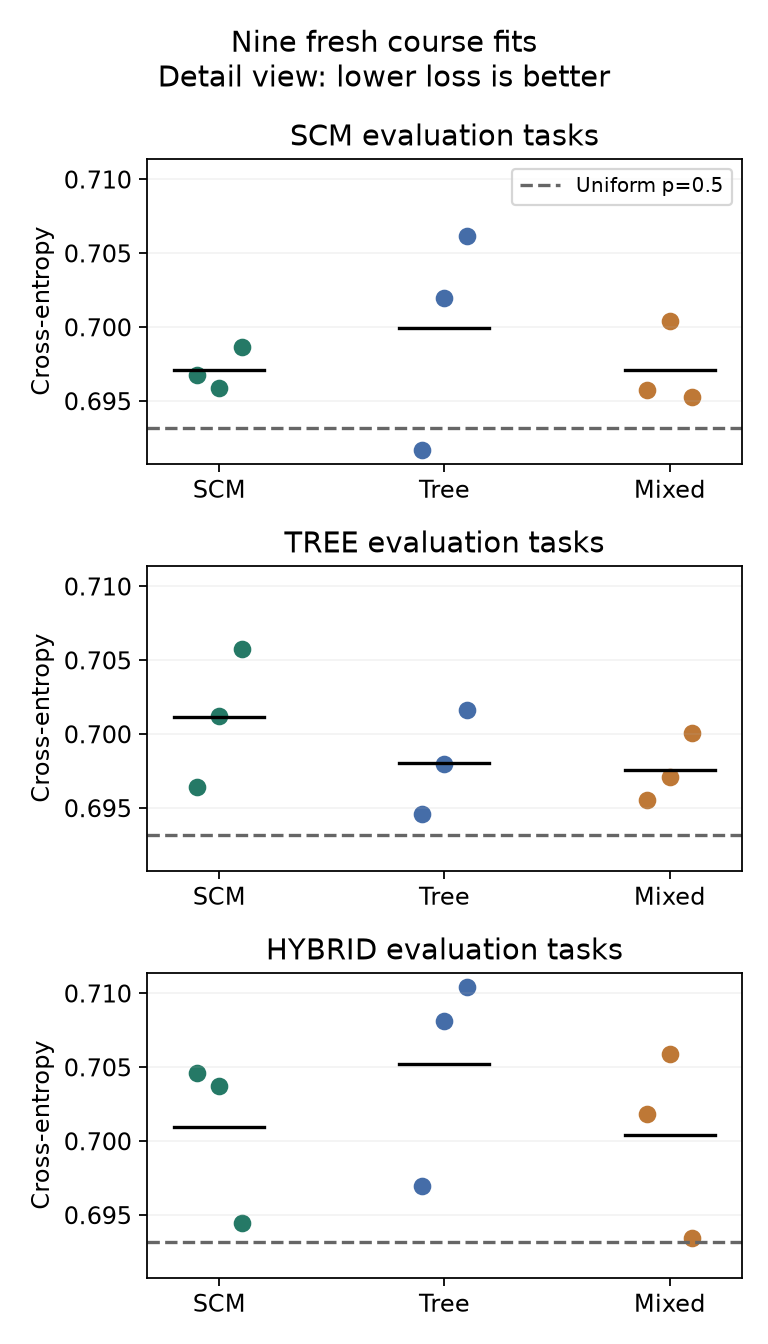

Every mean exceeds uniform CE. Near-chance performance limits any story about beneficial prior diversity.

## EXIT · Written defense

Explain: (1) what is held fixed and varied; (2) why an outer mixture differs from hybrid mechanisms; (3) why a benchmark used for prior selection is development evidence; (4) what the uniform baseline reveals; (5) which original Table12 artifacts remain missing. Predict how query-label input would invalidate the experiment. Submit your answer to the agent; passing author checks cannot satisfy it.

In [16]:
submission=dict(status='PENDING_WRITTEN_DEFENSE',prediction_replay_max_error=maximum,course_fits=course['fits'],paper_status=source['status'])
Path('b06-submission.json').write_text(json.dumps(submission,indent=2)+'\n')
print(submission)


{'status': 'PENDING_WRITTEN_DEFENSE', 'prediction_replay_max_error': 0.0, 'course_fits': 9, 'paper_status': 'INCOMPLETE_SOURCE_PROTOCOL'}


## NEXT STEP · Two separate execution gates

The full fresh **course** command below runs the same visible source from the embedded package. It verifies that source matches your notebook definitions first. A new output directory preserves author evidence. Original **paper** preflight authenticates missing requirements and refuses dispatch. Replacing this gate with longer course training would not reproduce Mitra. USD10cap/8commitment stop;3600saggregate local numerical limit. Full paper training and liveColab NOT_RUN/NOT_CHECKED.

In [17]:
RUN_FRESH_COURSE=False
RUN_PAPER_REPRO=False
if RUN_FRESH_COURSE:
    # Confirm the extracted canonical file matches all live implementation definitions.
    namespace={};exec((lab/'relkit/prior_b06.py').read_text(),namespace)
    for name in ['choose_prior','support_normalize','paired_effect','make_task','train_one','predict_tasks']:
        assert globals()[name].__code__.co_code==namespace[name].__code__.co_code, name
    subprocess.check_call([sys.executable,str(lab/'_budget_b06.py'),sys.executable,str(lab/'_run_b06.py'),'--output',str(evidence/'fresh-course-runs')])
if RUN_PAPER_REPRO:
    subprocess.check_call([sys.executable,str(lab/'_reproduce_b06.py'),'--run'])


## Source/protocol audit

Original Mitra:12layers,width512,4heads,72Mparameters;45million synthetic tasks; support quantile transform then standardization. Course:2layers,width32,640tasks per fit,support standardization,proxy generators. Mitra-v2 Hybrid SCM is not the additive course hybrid. Fine-tuning changes downstream weights; forward ICL does not.

The complete protocol and pinned source inventory are in the extracted package. `python b06-portable/labs/_reproduce_b06.py` lists the missing original6checkpoint/training histories, TabRepo folds and original evaluator/predictions. The current finetuning source targets v2. Original source parity is NOT_ESTABLISHED.

Primary readings: [Mitra](https://arxiv.org/html/2510.21204v1#S3), [Mitra-v2](https://arxiv.org/html/2609.04540v1#S2). Ask the agent for feedback and revisit after1/7/30days following your completion.